<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/_banners/opim5509_banner.svg" width="100%" alt="OPIM 5509 banner"/>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/Multivariate_Occupancy_RNN.ipynb)

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 9 — Multivariate RNN Pt 1: split_sequences, column order, the classification head
- Multivariate differs only in prep: all X on the left, TARGET AS THE LAST COLUMN (drop the date); look-back is the hyperparameter.
- split_sequences with look-back 10 -> 2,655 samples of 10 x features; the -1 predicts the NEXT step.
- SimpleRNN with a sigmoid head, n_steps / n_features inherited from the shape; if it learns in one epoch, add dropout.
- Show the time-series plot even for classification - it misses the quick in/out transitions.
-->


# Multivariate Occupancy Example (RNN), Part 1: Classify the Room
----------------------------
**Dr. Dave Wanik - University of Connecticut**

Let's see if we can predict whether a room is occupied as a function of its environmental sensor data (temperature, humidity, light, CO2).

Link: http://archive.ics.uci.edu/ml/datasets/Occupancy+Detection+

Same flow as before, just need to prep our data differently. For now, we ignore the time dimension but we could resample to a regular resolution.

Wow - also a nice example: https://machinelearningmastery.com/multivariate-time-series-forecasting-lstms-keras/

In [1]:
# standard modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# RNN-specific modules
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report,accuracy_score
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, GRU, LSTM
from tensorflow.keras.callbacks import EarlyStopping

# reproducibility: same seed every run (numbers on CPU match exactly; a GPU may drift a little)
import keras
keras.utils.set_random_seed(5509)


## Read in data
Check for missing values, make some plots.

In [2]:
# Dataset: UCI room-occupancy detection (Candanedo & Feldheim, 2016), originally from LuisM78's GitHub.
# We use the two real files - 8,143 minutes of training data (Feb 4-10) followed by 9,752 of test (Feb 11-18) -
# stacked in date order into one two-week series. (The 2-day datatest.txt slice was too short to learn from.)
base = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/data/"
df = pd.concat([pd.read_csv(base + "datatraining.txt"), pd.read_csv(base + "datatest2.txt")], ignore_index=True)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)   # chronological - never shuffle a time series
print(df.info())
df.head(n=15) # nice complete data! this will allow us to check our work later

<class 'pandas.DataFrame'>
RangeIndex: 17895 entries, 0 to 17894
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           17895 non-null  datetime64[us]
 1   Temperature    17895 non-null  float64       
 2   Humidity       17895 non-null  float64       
 3   Light          17895 non-null  float64       
 4   CO2            17895 non-null  float64       
 5   HumidityRatio  17895 non-null  float64       
 6   Occupancy      17895 non-null  int64         
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 978.8 KB
None


,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,2015-02-04 17:51:00,23.180,27.272000,426.0,721.250000,0.004793,1
1,2015-02-04 17:51:59,23.150,27.267500,429.5,714.000000,0.004783,1
2,2015-02-04 17:53:00,23.150,27.245000,426.0,713.500000,0.004779,1
3,2015-02-04 17:54:00,23.150,27.200000,426.0,708.250000,0.004772,1
4,2015-02-04 17:55:00,23.100,27.200000,426.0,704.500000,0.004757,1
5,2015-02-04 17:55:59,23.100,27.200000,419.0,701.000000,0.004757,1
6,2015-02-04 17:57:00,23.100,27.200000,419.0,701.666667,0.004757,1
7,2015-02-04 17:57:59,23.100,27.200000,419.0,699.000000,0.004757,1
8,2015-02-04 17:58:59,23.100,27.200000,419.0,689.333333,0.004757,1
9,2015-02-04 18:00:00,23.075,27.175000,419.0,688.000000,0.004745,1


In [3]:
# count of occupancy
df['Occupancy'].value_counts() # not perfectly balanced, but that's OK

Occupancy
0    14117
1     3778
Name: count, dtype: int64

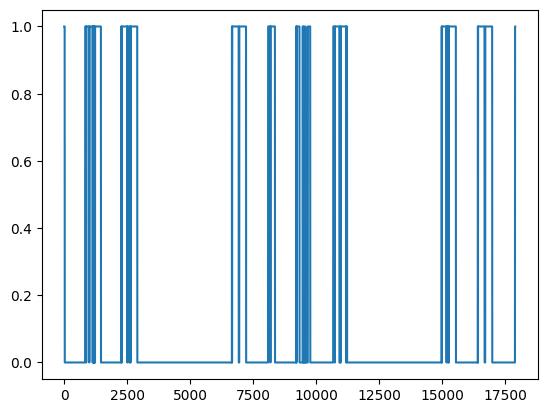

In [4]:
# visualize the data
df['Occupancy'].plot()
plt.show()

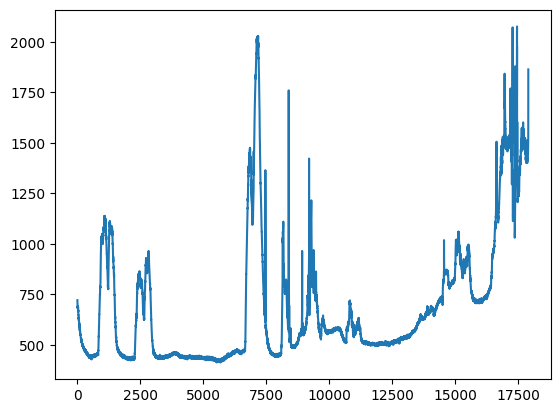

In [5]:
# visualize the data
df['CO2'].plot()
plt.show()

In [6]:
# drop the date column
df.drop(['date'], inplace=True, axis=1)
print(df.shape)
df.head()

(17895, 6)


,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,23.18,27.2720,426.0,721.25,0.004793,1
1,23.15,27.2675,429.5,714.00,0.004783,1
2,23.15,27.2450,426.0,713.50,0.004779,1
3,23.15,27.2000,426.0,708.25,0.004772,1
4,23.10,27.2000,426.0,704.50,0.004757,1


<!-- WINDOW-FN -->
## The window-making function: `split_sequences`

The multivariate version. Put the **target in the last column** first, then:

- **`n_steps`** is the **look-back**: each X is the last `n_steps` rows of **every column except the target**, shaped `(n_steps, n_features)`.
- The target y is the **last column at the final row of the window**, the same moment as the newest inputs.

For occupancy that's a **nowcast**: the sensors up to this minute say whether the room is occupied this minute.

Result: X is `(samples, n_steps, n_features)`, exactly what `input_shape=(n_steps, n_features)` expects.


In [7]:
# prep data for modeling (multivariate)
# link: https://machinelearningmastery.com/how-to-develop-lstm-models-for-time-series-forecasting/

from numpy import array

# split a multivariate sequence into samples
def split_sequences(sequences, n_steps):
	X, y = list(), list()
	for i in np.arange(len(sequences)): # be careful of this line!
		# find the end of this pattern
		end_ix = i + n_steps
		# check if we are beyond the dataset
		if end_ix > len(sequences):
			break
		# gather input and output parts of the pattern
		seq_x, seq_y = sequences[i:end_ix, :-1], sequences[end_ix-1, -1]
		X.append(seq_x)
		y.append(seq_y)
	return np.array(X), np.array(y)

In [8]:
# we could split our data first, normalize it, then create sequences

In [9]:
# all we need to do is decide on is n_steps (what our lookback period is)
# since we have a bunch of data, why not n_steps=10? then try 30 later on.
n_steps = 10
raw_seq = np.array(df) #make sure your data is stored as a numpy array!
# let's ignore the date column and just use the temperature data
X, y = split_sequences(raw_seq, n_steps=10)

In [10]:
# take a peak at what it did
print(X.shape)
print(y.shape)

# scroll up and make sure you understand this!
# y is a function of X (the previous n_steps observations!)

(17886, 10, 5)
(17886,)


In [11]:
# check the first few values
X[0]

array([[2.31800000e+01, 2.72720000e+01, 4.26000000e+02, 7.21250000e+02,
        4.79298818e-03],
       [2.31500000e+01, 2.72675000e+01, 4.29500000e+02, 7.14000000e+02,
        4.78344095e-03],
       [2.31500000e+01, 2.72450000e+01, 4.26000000e+02, 7.13500000e+02,
        4.77946352e-03],
       [2.31500000e+01, 2.72000000e+01, 4.26000000e+02, 7.08250000e+02,
        4.77150883e-03],
       [2.31000000e+01, 2.72000000e+01, 4.26000000e+02, 7.04500000e+02,
        4.75699293e-03],
       [2.31000000e+01, 2.72000000e+01, 4.19000000e+02, 7.01000000e+02,
        4.75699293e-03],
       [2.31000000e+01, 2.72000000e+01, 4.19000000e+02, 7.01666667e+02,
        4.75699293e-03],
       [2.31000000e+01, 2.72000000e+01, 4.19000000e+02, 6.99000000e+02,
        4.75699293e-03],
       [2.31000000e+01, 2.72000000e+01, 4.19000000e+02, 6.89333333e+02,
        4.75699293e-03],
       [2.30750000e+01, 2.71750000e+01, 4.19000000e+02, 6.88000000e+02,
        4.74535072e-03]])

In [12]:
# check Y
y[0]

np.float64(1.0)

## What exactly is one sample?

Say it out loud once and the rest of the notebook follows:

> **One sample is a ten-minute clip of the five sensors, and the model's job is to answer one question about it:
> was the room occupied at the *end* of the clip?**

That is what `split_sequences` just built, and two details in it catch everybody:

**1. The label is the LAST minute, not the whole window.** `y` comes from `sequences[end_ix-1, -1]` - the final row.
The other nine minutes are *context*, not answers. So a clip that starts empty and ends occupied is labelled
**occupied**, and that is not a mistake or an ambiguity: it is a clip of someone walking in.

**2. Occupancy is never an input.** `sequences[i:end_ix, :-1]` drops the last column, so the model sees the five
sensors and nothing else. It cannot peek at whether the room was occupied a minute ago. That is why the persistence
baseline - which *can* - is so hard to beat here, and it is the honest weakness of this dataset.

The cell below prints one sample so you can see the shape, then counts how often a clip straddles a change of
state, then prints one of those.

In [13]:
sensors = list(df.columns[:-1])                 # the 5 inputs; Occupancy is the target, and is NOT in X
idx = [f"t-{n_steps-1-i}" for i in range(n_steps)]   # t-9 (oldest) ... t-0 (the minute being classified)

print(f"X shape {X.shape} = (samples, minutes, sensors)   y shape {y.shape}")
print(f"\none sample - X[0] - is a {n_steps} x {len(sensors)} block:")
display(pd.DataFrame(X[0], columns=sensors, index=idx).round(2))
print(f"and its label is y[0] = {y[0]:.0f}  <- occupancy at t-0 ONLY")

# how often does the room change state inside a single window?
occ  = df["Occupancy"].values
wins = np.lib.stride_tricks.sliding_window_view(occ, n_steps)   # every window's occupancy, minute by minute
mixed = wins.min(axis=1) != wins.max(axis=1)

print(f"\nof {len(wins):,} windows:")
print(f"   pure  (all {n_steps} minutes the same state): {(~mixed).sum():>6,}   {(~mixed).mean():6.1%}")
print(f"   MIXED (the room changes mid-window)        : {mixed.sum():>6,}   {mixed.mean():6.1%}")
print(f"   of the mixed ones, {wins[mixed][:, -1].mean():.0%} are labelled occupied - about half walk-ins, half walk-outs")

# look at one of the mixed ones
m = int(np.argmax(mixed))
print(f"\nwindow {m} is mixed - occupancy minute by minute: {wins[m].astype(int)}")
print(f"its label is {wins[m][-1]:.0f}, because the label is always the last minute")
display(pd.DataFrame(X[m], columns=sensors, index=idx).round(2))

X shape (17886, 10, 5) = (samples, minutes, sensors)   y shape (17886,)

one sample - X[0] - is a 10 x 5 block:


,Temperature,Humidity,Light,CO2,HumidityRatio
t-9,23.18,27.27,426.0,721.25,0.0
t-8,23.15,27.27,429.5,714.00,0.0
t-7,23.15,27.24,426.0,713.50,0.0
t-6,23.15,27.20,426.0,708.25,0.0
t-5,23.10,27.20,426.0,704.50,0.0
t-4,23.10,27.20,419.0,701.00,0.0
t-3,23.10,27.20,419.0,701.67,0.0
t-2,23.10,27.20,419.0,699.00,0.0
t-1,23.10,27.20,419.0,689.33,0.0
t-0,23.08,27.18,419.0,688.00,0.0


and its label is y[0] = 1  <- occupancy at t-0 ONLY

of 17,886 windows:
   pure  (all 10 minutes the same state): 17,337    96.9%
   MIXED (the room changes mid-window)        :    549     3.1%
   of the mixed ones, 51% are labelled occupied - about half walk-ins, half walk-outs

window 7 is mixed - occupancy minute by minute: [1 1 1 1 1 1 1 1 1 0]
its label is 0, because the label is always the last minute


,Temperature,Humidity,Light,CO2,HumidityRatio
t-9,23.10,27.20,419.0,699.00,0.0
t-8,23.10,27.20,419.0,689.33,0.0
t-7,23.08,27.18,419.0,688.00,0.0
t-6,23.08,27.15,419.0,690.25,0.0
t-5,23.10,27.10,419.0,691.00,0.0
t-4,23.10,27.17,419.0,683.50,0.0
t-3,23.05,27.15,419.0,687.50,0.0
t-2,23.00,27.12,419.0,686.00,0.0
t-1,23.00,27.12,418.5,680.50,0.0
t-0,23.00,27.20,0.0,681.50,0.0


Only about **3%** of windows are mixed - but those are the interesting 3%. They are the transitions, and they
are exactly where you will see the model's probability wobble around 0.5 in the plots below. A pure window is an
easy question. A mixed one asks *"did they just arrive, or just leave?"*

In [14]:
# split the data into train and test partitions
# we will use 50% of the data for train, and 50% for validation
train_pct_index = int(0.5 * len(X))
X_train, X_test = X[:train_pct_index], X[train_pct_index:]
y_train, y_test = y[:train_pct_index], y[train_pct_index:]

# pretty slick way of splitting your data using slicing!
# notice how we didn't do any shuffling (we don't want temporal leakage! keeps time series intact)

In [15]:
# check the shape to be sure
print(X.shape, X_train.shape, X_test.shape)
print(y.shape, y_train.shape, y_test.shape)

# verify that this all adds up!
# 2635 samples with 30 lookback and 6 columns

(17886, 10, 5) (8943, 10, 5) (8943, 10, 5)
(17886,) (8943,) (8943,)


## One helper to score every model

Every model below gets the same treatment, so they are comparable: **train and test**, the F1 for each, the test
confusion matrix, and two pictures.

The important choice here is that we plot **`model.predict()` directly - the probability - and never the rounded
class**. Rounding to 0/1 throws away the only interesting part, which is *how sure the model was*. A model that
says 0.51 and a model that says 0.99 both round to "occupied", and you want to be able to tell them apart.

In [16]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score

scores = {}
confidence = {}

def show_results(name, model):
    """Train and test for a classifier - and we plot the PROBABILITY the model reports, never the rounded class.
    Rounding throws away the only interesting part: how SURE the model was.

    The plot is P(occupied) over time, with the true occupancy shaded behind it, the 0.5 threshold dashed,
    and a black dot on every window the model got wrong."""
    p_tr = model.predict(X_train, verbose=0).ravel()
    p_te = model.predict(X_test,  verbose=0).ravel()
    f1_tr = f1_score(y_train, (p_tr >= 0.5).astype(int), average="weighted")
    f1_te = f1_score(y_test,  (p_te >= 0.5).astype(int), average="weighted")
    scores[name] = f1_te
    # how DECISIVE is it? the share of predictions that are not hedging near 0.5
    sure_tr = ((p_tr < 0.1) | (p_tr > 0.9)).mean()
    sure_te = ((p_te < 0.1) | (p_te > 0.9)).mean()
    scores[name] = f1_te
    confidence[name] = sure_te
    print(f"{name}:  train F1 = {f1_tr:.3f}   test F1 = {f1_te:.3f}   (gap {f1_te - f1_tr:+.3f})")
    print(f"{' ' * len(name)}   confident calls (P below 0.1 or above 0.9): "
          f"train {sure_tr:.1%}   test {sure_te:.1%}")
    print("\nconfusion matrix (test):")
    print(confusion_matrix(y_test, (p_te >= 0.5).astype(int)))
    print(classification_report(y_test, (p_te >= 0.5).astype(int), digits=3))

    SLICE = 1500                    # how much of the TIMELINE to draw - the whole test set at once is a barcode
    fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=False)
    for r, (split, y_true, p) in enumerate([("train", y_train, p_tr), ("test", y_test, p_te)]):
        start = int(np.argmax(np.abs(np.diff(y_true)) > 0))          # start at the first change of state
        sl = slice(start, start + SLICE)
        t = np.arange(len(y_true))[sl]
        ax[r].fill_between(t, 0, y_true[sl], step="mid", color="#C8E6C9", label="TRUTH: room was occupied (shaded)")
        ax[r].plot(t, p[sl], color="#C62828", lw=1.0, label="MODEL: P(occupied) (red line)")
        ax[r].axhline(0.5, color="#616161", ls="--", lw=0.8)
        ax[r].set_ylim(-0.05, 1.05); ax[r].set_ylabel("P(occupied)")
        ax[r].set_title(f"{name} - {split} set (zoomed in)")
        ax[r].legend(loc="center left", fontsize=8, framealpha=0.9)
        wrong = (p[sl] >= 0.5) != (y_true[sl] >= 0.5)
        ax[r].scatter(t[wrong], p[sl][wrong], s=9, color="black", zorder=5,
                         label="the model got these wrong")
    ax[1].set_xlabel("time step (minute)")
    plt.tight_layout(); plt.show()

In [17]:
def metrics_table(y_true_cls, y_pred_cls, labels=("empty", "occupied")):
    """Every intermediate number behind accuracy / macro F1 / weighted F1 - shown, not asserted."""
    y_true_cls = np.asarray(y_true_cls).astype(int).ravel()
    y_pred_cls = np.asarray(y_pred_cls).astype(int).ravel()
    rows = []
    for k, cname in enumerate(labels):
        tp = int(((y_pred_cls == k) & (y_true_cls == k)).sum())
        fp = int(((y_pred_cls == k) & (y_true_cls != k)).sum())
        fn = int(((y_pred_cls != k) & (y_true_cls == k)).sum())
        prec = tp / (tp + fp) if tp + fp else 0.0
        rec  = tp / (tp + fn) if tp + fn else 0.0
        f1   = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
        n_c  = int((y_true_cls == k).sum())
        rows.append({"class": cname, "TP": tp, "FP": fp, "FN": fn,
                     "precision": round(prec, 4), "recall": round(rec, 4), "F1": round(f1, 4),
                     "support n_c": n_c, "n_c x F1": round(n_c * f1, 1)})
    t = pd.DataFrame(rows).set_index("class")
    N = int(t["support n_c"].sum()); correct = int((y_pred_cls == y_true_cls).sum())
    macro = t["F1"].mean(); weighted = t["n_c x F1"].sum() / N
    display(t)
    print(f"accuracy    = correct / all     = {correct:,} / {N:,} = {correct/N:.4f}")
    print(f"macro F1    = (F1_0 + F1_1) / 2 = ({t['F1'].iloc[0]:.4f} + {t['F1'].iloc[1]:.4f}) / 2 = {macro:.4f}")
    print(f"weighted F1 = sum(n_c x F1) / N = {t['n_c x F1'].sum():,.1f} / {N:,} = {weighted:.4f}")
    return {"accuracy": correct/N, "macro F1": macro, "weighted F1": weighted}

> **Careful with the word "window".** The x-axis below is the **calendar** - we draw 1,500 consecutive minutes so
> the chart is readable instead of a 9,000-minute barcode. That is a completely different thing from the model's
> **look-back window**, which is only a handful of minutes and is what each single dot on that line was computed
> from. One point on the red line = one sample = one look-back window.

### Reading the classification report

Three numbers get reported and they answer three different questions. Everything comes out of the confusion matrix:

|  | predicted empty | predicted occupied |
| :-- | :-: | :-: |
| **was empty** | TN | FP |
| **was occupied** | FN | TP |

**Per class**, "precision" is how often it was right when it said so, and "recall" is how much of the class it
caught. $F_1$ is their harmonic mean, which punishes a model that buys one by giving up the other:

$$
\text{precision} = \frac{TP}{TP + FP}, \qquad
\text{recall} = \frac{TP}{TP + FN}, \qquad
F_1 = 2\,\frac{\text{precision}\cdot\text{recall}}{\text{precision} + \text{recall}}
$$

**Accuracy** ignores classes entirely - it is just the share of rows on the diagonal:

$$
\text{accuracy} = \frac{TP + TN}{\text{all windows}}
$$

**The two averages** differ only in what they weight by. Let $n_c$ be the **support** of class $c$ - how many test
windows actually belong to it:

$$
\text{macro } F_1 = \frac{1}{C}\sum_{c} F_1^{(c)}
\qquad\qquad
\text{weighted } F_1 = \frac{\sum_c n_c\,F_1^{(c)}}{\sum_c n_c}
$$

**Macro treats the two classes as equally important.** **Weighted treats every window as equally important**, so
the big class dominates it.

#### Worked, with this notebook's LSTM

| class | precision | recall | $F_1$ | support |
| :-- | --: | --: | --: | --: |
| empty | 0.972 | 0.968 | 0.970 | 7,108 |
| occupied | 0.878 | 0.892 | 0.885 | 1,835 |

$$
\text{macro } F_1 = \frac{0.970 + 0.885}{2} = 0.9275 \approx \mathbf{0.928}
$$

$$
\text{weighted } F_1 = \frac{0.970(7{,}108) + 0.885(1{,}835)}{8{,}943} = \frac{8{,}519}{8{,}943} = \mathbf{0.953}
$$

Weighted comes out higher because the class the model is better at is also the class that is four times bigger.

#### Why we bother reporting all three

Put the majority-class baseline - the one that never says "occupied" - next to the LSTM:

| model | accuracy | weighted $F_1$ | macro $F_1$ |
| :-- | --: | --: | --: |
| always guess "empty" | 0.795 | 0.704 | **0.443** |
| LSTM(30) | 0.952 | 0.953 | **0.928** |

**Accuracy says the useless model is 80% right.** Weighted $F_1$ is suspicious of it. **Macro $F_1$ exposes it**,
because the occupied class scores $F_1 = 0$ and macro refuses to let the big class hide that.

Rule of thumb: on imbalanced data, quote **macro** when both classes matter to you - and for a room-occupancy
sensor, detecting the *occupied* minutes is the entire point.

# RNN one layer model

In [18]:
# define
n_steps = X_train.shape[1]
n_features = X_train.shape[2]

print(n_steps, n_features)

10 5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 30)             │         1,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,111 (4.34 KB)

 Trainable params: 1,111 (4.34 KB)

 Non-trainable params: 0 (0.00 B)

...

 88/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9760 - loss: 0.1525

105/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9754 - loss: 0.1464

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.9744 - loss: 0.1485 - val_acc: 0.8765 - val_loss: 1.1336


Epoch 11: early stopping


Restoring model weights from the end of the best epoch: 1.


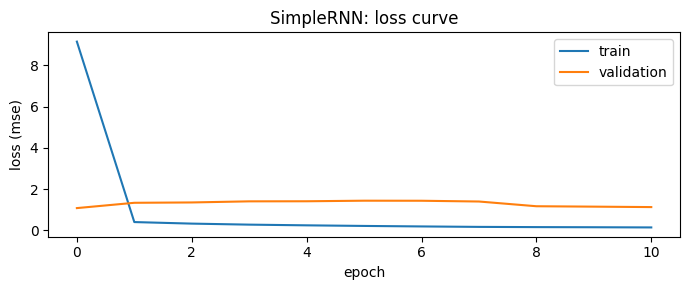

stopped after 11 epochs; best validation loss 1.085


In [19]:
# now let's build a model
# NEED TO UPDATE FOR CLASSIFICATION

# define
n_steps = X_train.shape[1]
n_features = X_train.shape[2]

# define model
model = Sequential()
model.add(Input(shape=(n_steps,n_features)))
model.add(SimpleRNN(30, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['acc'])


es = EarlyStopping(monitor='val_acc', mode='max',
                   patience=10,
                   verbose=1,
                   restore_best_weights=True)

# fit model (uses early stopping)
history = model.fit(X_train, y_train,
          epochs=500,
          batch_size=64,
          validation_split=0.2, # val is a random 20% of the data since we set shuffle = True
          verbose=1,
          callbacks=[es],
          shuffle=True)

# the loss curve - always keep the History object that fit() hands back
plt.figure(figsize=(7, 3))
plt.plot(history.history["loss"], label="train")
if "val_loss" in history.history:
    plt.plot(history.history["val_loss"], label="validation")
plt.xlabel("epoch"); plt.ylabel("loss (mse)"); plt.title("SimpleRNN: loss curve")
plt.legend(); plt.tight_layout(); plt.show()

print(f"stopped after {len(history.history['loss'])} epochs;"
      f" best validation loss {min(history.history['val_loss']):.3f}")

SimpleRNN(30):  train F1 = 0.931   test F1 = 0.952   (gap +0.022)
                confident calls (P below 0.1 or above 0.9): train 95.4%   test 95.0%

confusion matrix (test):
[[6957  151]
 [ 270 1565]]
              precision    recall  f1-score   support

         0.0      0.963     0.979     0.971      7108
         1.0      0.912     0.853     0.881      1835

    accuracy                          0.953      8943
   macro avg      0.937     0.916     0.926      8943
weighted avg      0.952     0.953     0.952      8943



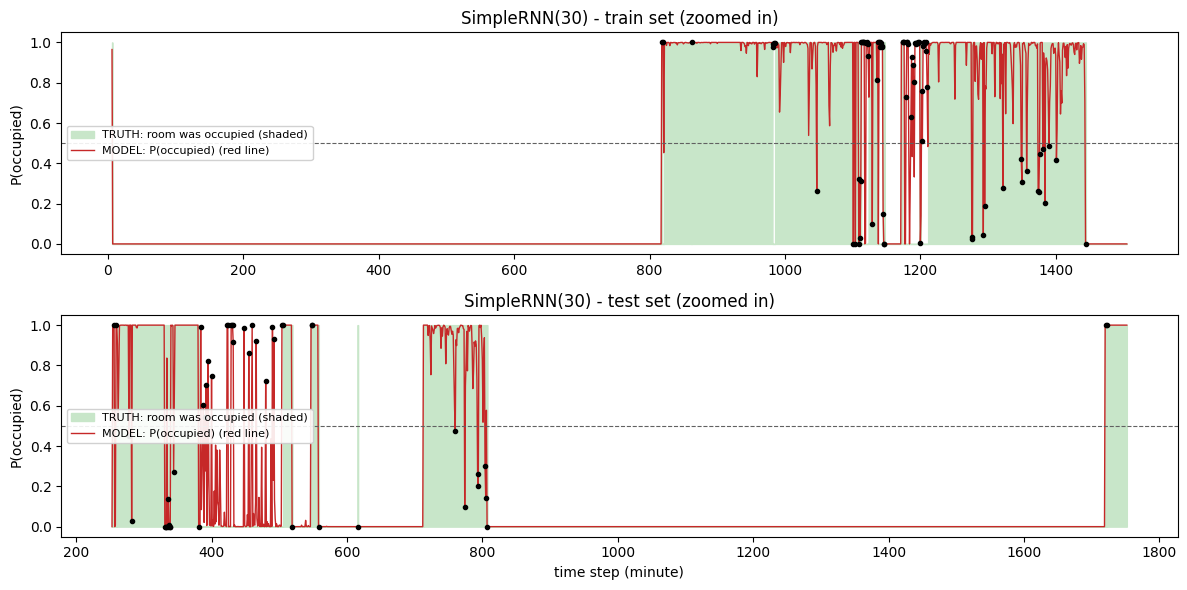

In [20]:
show_results("SimpleRNN(30)", model)

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 10 — Multivariate RNN Pt 2: LSTM swap, stacking, persistence baseline
- One-word LSTM swap: (features + units) x units + bias, x4 = 4,320 params.
- It predicts the zeros a bit better; weighted F1 comparable.
- Stacked SimpleRNN with return_sequences=True keeps the 10 x 30 sequence into a second RNN - and does WORSE here: too complex for an easy problem.
- Persistence is brutal to beat - show value over the dummy every time.
-->


# LSTM one layer model
Literally, just grab the code above and change SimpleRNN to LSTM and boom! you have a more sophisticated model.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30)             │         4,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,351 (17.00 KB)

 Trainable params: 4,351 (17.00 KB)

 Non-trainable params: 0 (0.00 B)

...

100/112 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9781 - loss: 0.1043

111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9761 - loss: 0.1126

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.9762 - loss: 0.1119 - val_acc: 0.9743 - val_loss: 0.0768


Epoch 32: early stopping


Restoring model weights from the end of the best epoch: 22.


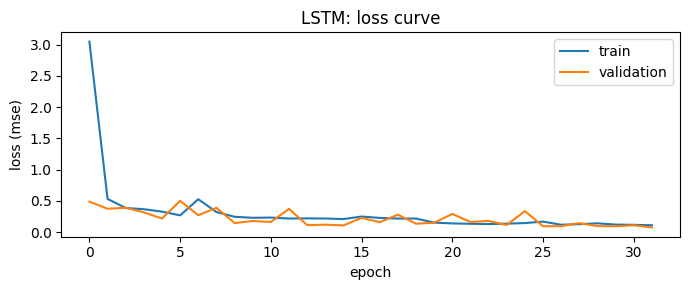

stopped after 32 epochs; best validation loss 0.077


In [21]:
# now let's build a model

# since this is a univariate problem, n_features will be 1 (we also defined this before)

# define model
model = Sequential()
model.add(Input(shape=(n_steps,n_features)))
model.add(LSTM(30, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['acc'])
model.summary()

es = EarlyStopping(monitor='val_acc',
                   mode='max',
                   patience=10,
                   verbose=1,
                   restore_best_weights=True)

# fit model (uses early stopping)
history = model.fit(X_train, y_train,
          epochs=500,
          batch_size=64,
          validation_split=0.2, # val is a random 20% of the data since we set shuffle = True
          verbose=1,
          callbacks=[es],
          shuffle=True)

# the loss curve - always keep the History object that fit() hands back
plt.figure(figsize=(7, 3))
plt.plot(history.history["loss"], label="train")
if "val_loss" in history.history:
    plt.plot(history.history["val_loss"], label="validation")
plt.xlabel("epoch"); plt.ylabel("loss (mse)"); plt.title("LSTM: loss curve")
plt.legend(); plt.tight_layout(); plt.show()

print(f"stopped after {len(history.history['loss'])} epochs;"
      f" best validation loss {min(history.history['val_loss']):.3f}")

LSTM(30):  train F1 = 0.981   test F1 = 0.953   (gap -0.029)
           confident calls (P below 0.1 or above 0.9): train 95.8%   test 96.3%

confusion matrix (test):
[[6881  227]
 [ 198 1637]]
              precision    recall  f1-score   support

         0.0      0.972     0.968     0.970      7108
         1.0      0.878     0.892     0.885      1835

    accuracy                          0.952      8943
   macro avg      0.925     0.930     0.928      8943
weighted avg      0.953     0.952     0.953      8943



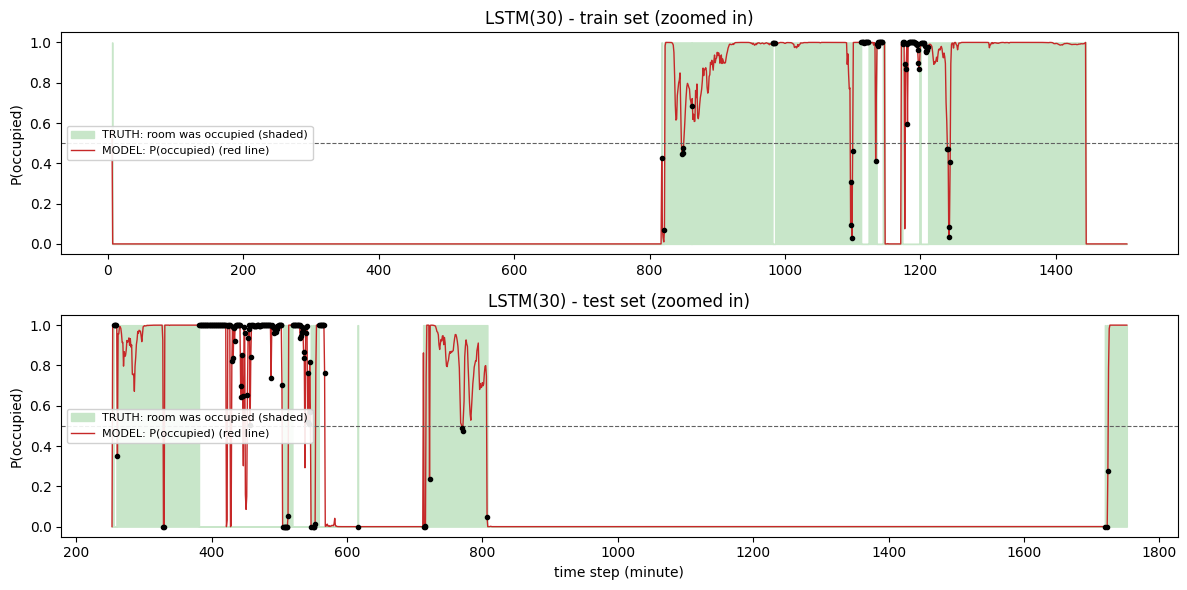

In [22]:
show_results("LSTM(30)", model)

# RNN two layer model
Don't forget to set return_sequences=True!

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 10, 30)         │         1,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,941 (11.49 KB)

 Trainable params: 2,941 (11.49 KB)

 Non-trainable params: 0 (0.00 B)

...

 96/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9720 - loss: 0.0892

106/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9705 - loss: 0.0910

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.9698 - loss: 0.0916 - val_acc: 0.9732 - val_loss: 0.0528


Epoch 13: early stopping


Restoring model weights from the end of the best epoch: 3.


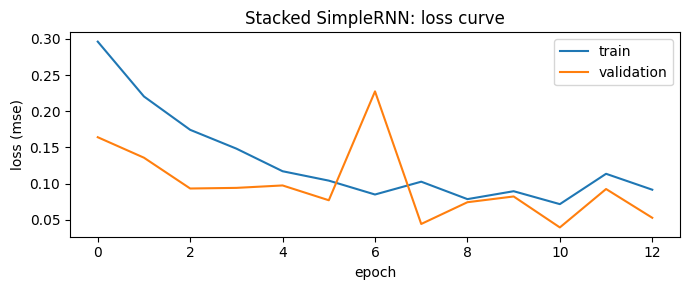

stopped after 13 epochs; best validation loss 0.039


In [23]:
# now let's build a model

# since this is a univariate problem, n_features will be 1 (we also defined this before)

# define model
model = Sequential()
model.add(Input(shape=(n_steps,n_features)))
model.add(SimpleRNN(30, return_sequences=True, activation='relu'))
                                    # note that the output when
                                    # return_sequences=True makes the output [n_steps, features]
                                    # where rows = n_steps (10!) and features = hidden size (30!)
model.add(SimpleRNN(30)) # output is a simple vector [1,30] that goes into a dense layer
                          # NO RETURN_SEQUENCES!!!
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['acc'])
model.summary()

es = EarlyStopping(monitor='val_acc', mode='max',
                   patience=10,
                   verbose=1,
                   restore_best_weights=True)

# fit model (uses early stopping)
history = model.fit(X_train, y_train,
          epochs=500,
          batch_size=64,
          validation_split=0.2, # val is a random 20% of the data since we set shuffle = True
          verbose=1,
          callbacks=[es],
          shuffle=True)

# the loss curve - always keep the History object that fit() hands back
plt.figure(figsize=(7, 3))
plt.plot(history.history["loss"], label="train")
if "val_loss" in history.history:
    plt.plot(history.history["val_loss"], label="validation")
plt.xlabel("epoch"); plt.ylabel("loss (mse)"); plt.title("Stacked SimpleRNN: loss curve")
plt.legend(); plt.tight_layout(); plt.show()

print(f"stopped after {len(history.history['loss'])} epochs;"
      f" best validation loss {min(history.history['val_loss']):.3f}")

stacked SimpleRNN(30) x2:  train F1 = 0.964   test F1 = 0.941   (gap -0.023)
                           confident calls (P below 0.1 or above 0.9): train 69.6%   test 69.5%

confusion matrix (test):
[[6846  262]
 [ 266 1569]]
              precision    recall  f1-score   support

         0.0      0.963     0.963     0.963      7108
         1.0      0.857     0.855     0.856      1835

    accuracy                          0.941      8943
   macro avg      0.910     0.909     0.909      8943
weighted avg      0.941     0.941     0.941      8943



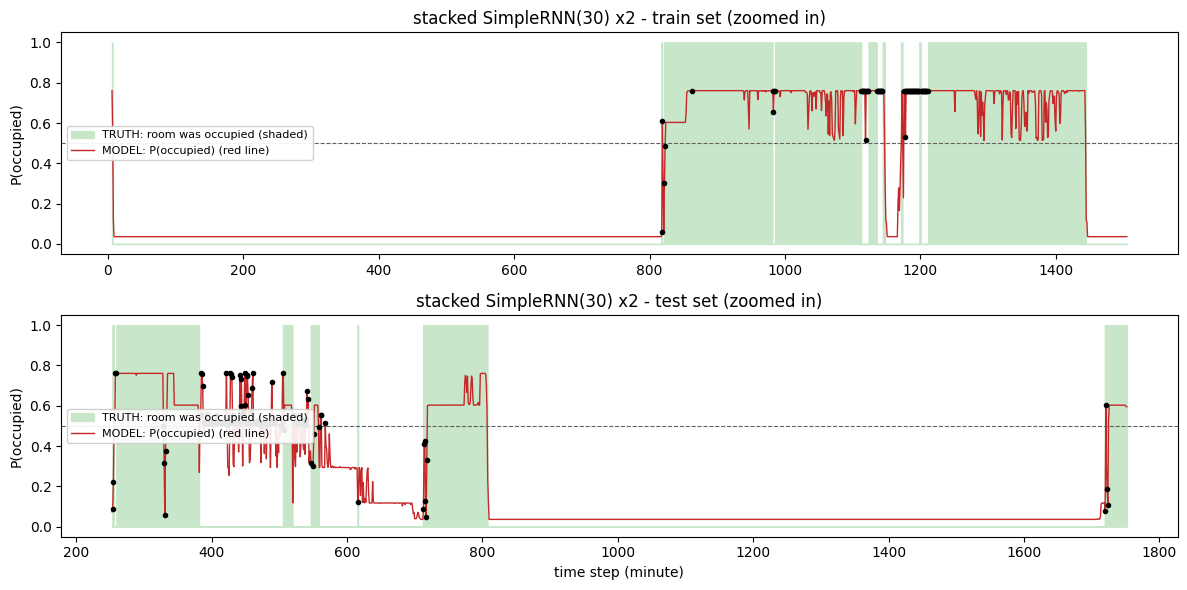

In [24]:
show_results("stacked SimpleRNN(30) x2", model)

## Save the model and use it again

Reproducibility means more than a seed: **save the fitted model** so you (or a teammate, or your future self) can reload it and predict without retraining. Keras 3 saves to a single `.keras` file. The reloaded model must give *identical* predictions - we check.

In [25]:
from keras.models import load_model

model.save('Multivariate_Occupancy_RNN.keras')                 # one file: architecture + weights + optimizer state
reloaded = load_model('Multivariate_Occupancy_RNN.keras')

# same inputs, same answers?
import numpy as np
same = np.allclose(model.predict(X_test[:5], verbose=0), reloaded.predict(X_test[:5], verbose=0))
print('reloaded model reproduces the predictions:', same)
reloaded.summary()

reloaded model reproduces the predictions: True


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 10, 30)         │         1,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,825 (34.48 KB)

 Trainable params: 2,941 (11.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,884 (22.99 KB)

## Did we beat the dumb models?

Same question as the temperature notebook, and it matters more here, because **accuracy lies when the classes are
imbalanced**. The room is empty most of the time, so a model that never predicts "occupied" at all still scores
well on accuracy. That is why we report **weighted F1** and always print the confusion matrix.

In [26]:
# baseline model - prediction is just the previous time step (a tough one to beat!)
df['Baseline'] = df['Occupancy'].shift(1)
df.head()

,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy,Baseline
0,23.18,27.2720,426.0,721.25,0.004793,1,NaN
1,23.15,27.2675,429.5,714.00,0.004783,1,1.0
2,23.15,27.2450,426.0,713.50,0.004779,1,1.0
3,23.15,27.2000,426.0,708.25,0.004772,1,1.0
4,23.10,27.2000,426.0,704.50,0.004757,1,1.0


In [27]:
y_test_baseline = df['Baseline']
# just extract rows corresponding to y_test
y_test_baseline = y_test_baseline.tail(y_test.shape[0])
# verify shape
print(y_test.shape)
print(y_test_baseline.shape) # good!

(8943,)
(8943,)


### Baseline 1: always guess the majority class

The room is empty most of the time, so "it is always empty" is a surprisingly hard accuracy to beat - and a
completely useless model. This is the number that shows why accuracy alone is the wrong score.

In [28]:
from sklearn.metrics import accuracy_score

majority = int(round(y_train.mean()))          # whichever class dominates the TRAINING data
maj_test = np.full(len(y_test), majority)

print(f"the training set is {100*(1-y_train.mean()):.1f}% empty, so the majority guess is '{majority}'")
print(f"majority class:  accuracy = {accuracy_score(y_test, maj_test):.3f}"
      f"   weighted F1 = {f1_score(y_test, maj_test, average='weighted'):.3f}")
print("\nhigh accuracy, useless model - it never once says 'occupied':")
print(confusion_matrix(y_test, maj_test))
scores["majority class (always empty)"] = f1_score(y_test, maj_test, average="weighted")

the training set is 78.4% empty, so the majority guess is '0'
majority class:  accuracy = 0.795   weighted F1 = 0.704

high accuracy, useless model - it never once says 'occupied':
[[7108    0]
 [1835    0]]


### Balanced vs imbalanced: why one score is not enough

The room is empty **78%** of the time, so the classes are badly imbalanced. That single fact is what makes
`accuracy` untrustworthy here, and the table below shows exactly where the three summary numbers come from so you
can see it rather than take my word for it.

$$\text{macro } F_1 = \frac{1}{C}\sum_c F_1^{(c)} \qquad\qquad
\text{weighted } F_1 = \frac{\sum_c n_c F_1^{(c)}}{\sum_c n_c}$$

Same per-class $F_1$ values, different weights. **Macro** gives the two classes equal say. **Weighted** gives every
*window* equal say, so the big class runs the show.

Run it on a real model and on the do-nothing baseline, and watch which number notices the difference.

In [29]:
print("=" * 62)
print("A REAL MODEL")
print("=" * 62)
m_model = metrics_table(y_test, (model.predict(X_test, verbose=0).ravel() >= 0.5))

print()
print("=" * 62)
print("THE DO-NOTHING BASELINE: always guess 'empty'")
print("=" * 62)
m_dumb = metrics_table(y_test, np.zeros(len(y_test)))

print()
display(pd.DataFrame({"a real model": m_model, "always guess empty": m_dumb}).round(3))
print("Accuracy barely drops. Weighted F1 gets suspicious. MACRO F1 collapses -")
print("because the 'occupied' class scores F1 = 0 and macro refuses to let the big class hide it.")
print("\nOn imbalanced data, quote MACRO when both classes matter - and here, catching the")
print("occupied minutes is the entire reason the sensor exists.")

A REAL MODEL


,TP,FP,FN,precision,recall,F1,support n_c,n_c x F1
class,,,,,,,,
empty,6846,266,262,0.9626,0.9631,0.9629,7108,6844.1
occupied,1569,262,266,0.8569,0.8550,0.8560,1835,1570.7


accuracy    = correct / all     = 8,415 / 8,943 = 0.9410
macro F1    = (F1_0 + F1_1) / 2 = (0.9629 + 0.8560) / 2 = 0.9094
weighted F1 = sum(n_c x F1) / N = 8,414.8 / 8,943 = 0.9409

THE DO-NOTHING BASELINE: always guess 'empty'


,TP,FP,FN,precision,recall,F1,support n_c,n_c x F1
class,,,,,,,,
empty,7108,1835,0,0.7948,1.0,0.8857,7108,6295.4
occupied,0,0,1835,0.0000,0.0,0.0000,1835,0.0


accuracy    = correct / all     = 7,108 / 8,943 = 0.7948
macro F1    = (F1_0 + F1_1) / 2 = (0.8857 + 0.0000) / 2 = 0.4429
weighted F1 = sum(n_c x F1) / N = 6,295.4 / 8,943 = 0.7039



,a real model,always guess empty
accuracy,0.941,0.795
macro F1,0.909,0.443
weighted F1,0.941,0.704


Accuracy barely drops. Weighted F1 gets suspicious. MACRO F1 collapses -
because the 'occupied' class scores F1 = 0 and macro refuses to let the big class hide it.

On imbalanced data, quote MACRO when both classes matter - and here, catching the
occupied minutes is the entire reason the sensor exists.


### Baseline 2: persistence (the previous minute)

"This minute looks like the one before it." On a room that stays occupied or empty for long stretches, this is a
very strong baseline - and that is the honest problem with this dataset, which we come back to at the end.

persistence: train F1 = 0.995   test F1 = 0.995


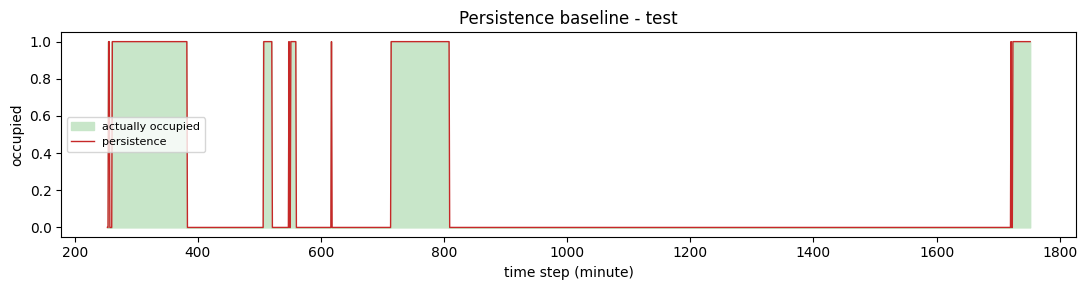

In [30]:
# the persistence baseline: predict that this minute looks like the previous one
base = df['Baseline'].values[n_steps - 1:]          # line it up with the windows split_sequences made
base_train, base_test = base[:train_pct_index], base[train_pct_index:train_pct_index + len(y_test)]

from sklearn.metrics import f1_score
print(f"persistence: train F1 = {f1_score(y_train, base_train, average='weighted'):.3f}"
      f"   test F1 = {f1_score(y_test, base_test, average='weighted'):.3f}")
scores['persistence (previous minute)'] = f1_score(y_test, base_test, average='weighted')

WIN = 1500
start = int(np.argmax(np.abs(np.diff(y_test)) > 0))
sl = slice(start, start + WIN); t = np.arange(len(y_test))[sl]
plt.figure(figsize=(11, 3))
plt.fill_between(t, 0, y_test[sl], step='mid', color='#C8E6C9', label='actually occupied')
plt.plot(t, base_test[sl], color='#C62828', lw=1.0, label='persistence')
plt.ylabel('occupied'); plt.xlabel('time step (minute)'); plt.legend(loc='center left', fontsize=8)
plt.title('Persistence baseline - test'); plt.tight_layout(); plt.show()

# looks good, BUT it's not a smart model! all it does is shift the answer by one minute.
# THIS is the number every model above has to beat.

In [31]:
# be careful of the baseline model
# and make sure you choose an appropriate measure
# for the problem you are trying to solve...